In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt


np.random.seed(42)
tf.random.set_seed(42)

CWD = Path.cwd()
MODELS_DIR = CWD / "models" if (CWD / "models").exists() else CWD
PROJECT_ROOT = MODELS_DIR.parent

DATASET_DIR = PROJECT_ROOT / "data" / "inverse_rendering_dataset"
METADATA_PATH = DATASET_DIR / "metadata.csv"

ANGULAR_MODEL_PATH = MODELS_DIR / "angular_predictor.keras"
COLOR_MODEL_PATH = MODELS_DIR / "color_power_predictor.keras"

OUTPUT_ANGULAR_PATH = MODELS_DIR / "angular_predictor_finetuned.keras"
OUTPUT_COLOR_PATH = MODELS_DIR / "color_power_predictor_finetuned.keras"

LEGACY_MASTER_CSV = PROJECT_ROOT / "processing" / "master_with_paths.csv"
LEGACY_COLOR_CSV = PROJECT_ROOT / "processing" / "color_power_labels.csv"

print("Metadata:", METADATA_PATH)
print("Angular model:", ANGULAR_MODEL_PATH)
print("Color/power model:", COLOR_MODEL_PATH)

Metadata: /home/kaclark219/Documents/Programming/xrlive/inverse-rendering/data/inverse_rendering_dataset/metadata.csv
Angular model: /home/kaclark219/Documents/Programming/xrlive/inverse-rendering/models/angular_predictor.keras
Color/power model: /home/kaclark219/Documents/Programming/xrlive/inverse-rendering/models/color_power_predictor.keras


In [26]:
def normalize_rows(v: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    n = np.linalg.norm(v, axis=1, keepdims=True)
    return v / np.clip(n, eps, None)


def ensure_cam_space_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    needed = {
        "light0_pos_cam_x", "light0_pos_cam_y", "light0_pos_cam_z",
        "light0_dir_cam_x", "light0_dir_cam_y", "light0_dir_cam_z",
    }
    if needed.issubset(out.columns) and out[list(needed)].notna().all().all():
        return out

    cam_pos = out[["cam_pos_x", "cam_pos_y", "cam_pos_z"]].to_numpy(dtype=np.float32)
    cam_right = normalize_rows(out[["cam_right_x", "cam_right_y", "cam_right_z"]].to_numpy(dtype=np.float32))
    cam_up = normalize_rows(out[["cam_up_x", "cam_up_y", "cam_up_z"]].to_numpy(dtype=np.float32))
    cam_forward = normalize_rows(out[["cam_forward_x", "cam_forward_y", "cam_forward_z"]].to_numpy(dtype=np.float32))
    cam_back = -cam_forward

    light_pos = out[["light0_pos_x", "light0_pos_y", "light0_pos_z"]].to_numpy(dtype=np.float32)
    light_dir = normalize_rows(out[["light0_dir_x", "light0_dir_y", "light0_dir_z"]].to_numpy(dtype=np.float32))

    rel = light_pos - cam_pos

    out["light0_pos_cam_x"] = np.einsum("ij,ij->i", rel, cam_right)
    out["light0_pos_cam_y"] = np.einsum("ij,ij->i", rel, cam_up)
    out["light0_pos_cam_z"] = np.einsum("ij,ij->i", rel, cam_back)

    out["light0_dir_cam_x"] = np.einsum("ij,ij->i", light_dir, cam_right)
    out["light0_dir_cam_y"] = np.einsum("ij,ij->i", light_dir, cam_up)
    out["light0_dir_cam_z"] = np.einsum("ij,ij->i", light_dir, cam_back)
    return out


def load_rgb_image(path: str, img_size: tuple[int, int]) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize(img_size, Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0

In [ ]:
df = pd.read_csv(METADATA_PATH, low_memory=False)

df["image_path"] = df["image_relpath"].astype(str).map(lambda rel: str(DATASET_DIR / rel))
if "image_exists" in df.columns:
    image_exists_mask = df["image_exists"].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df[image_exists_mask].copy()

df = df[df["image_path"].map(os.path.exists)].reset_index(drop=True)

df = df[(df["num_active_lights"] == 1) & (df["light0_type"].astype(str) == "SPOT")].reset_index(drop=True)

if df.empty:
    raise ValueError("No valid SPOT single-light rows found in metadata.")

print("Usable rows:", len(df))
print(df[["image_relpath", "light0_type", "light0_energy", "light0_color_r", "light0_color_g", "light0_color_b"]].head(3))

Usable rows: 1473
                                       image_relpath light0_type  \
0  images/single_light/base/default/000000_az000_...        SPOT   
1  images/single_light/base/default/000001_az015_...        SPOT   
2  images/single_light/base/default/000002_az030_...        SPOT   

   light0_energy  light0_color_r  light0_color_g  light0_color_b  
0         3000.0             1.0             1.0             1.0  
1         3000.0             1.0             1.0             1.0  
2         3000.0             1.0             1.0             1.0  


In [ ]:
angular_model = keras.models.load_model(ANGULAR_MODEL_PATH)
angular_img_h, angular_img_w = angular_model.input_shape[0][1:3]
angular_tab_dim = angular_model.input_shape[1][1]

angular_df = ensure_cam_space_columns(df)

target_cols_ang = [
    "light0_pos_cam_x", "light0_pos_cam_y", "light0_pos_cam_z",
    "light0_dir_cam_x", "light0_dir_cam_y", "light0_dir_cam_z",
]

X_ang_img = np.stack(
    [load_rgb_image(p, (angular_img_w, angular_img_h)) for p in angular_df["image_path"]],
    axis=0,
)
y_ang = angular_df[target_cols_ang].to_numpy(dtype=np.float32)

print("Angular image tensor:", X_ang_img.shape)
print("Angular target tensor:", y_ang.shape)
print("Angular model tab dim:", angular_tab_dim)

Angular image tensor: (1473, 224, 224, 3)
Angular target tensor: (1473, 6)
Angular model tab dim: 31


In [ ]:
legacy_df = pd.read_csv(LEGACY_MASTER_CSV, low_memory=False)
legacy_df = ensure_cam_space_columns(legacy_df)

legacy_filtered = legacy_df[
    legacy_df["light_folder"].astype(str).isin({"Spot Light"})
    & (legacy_df["num_active_lights"].astype(int) == 1)
    & (legacy_df["material_folder"].astype(str) == "PlasticGlossy")
    & (legacy_df["batch_folder"].astype(str) == "Batch 1 - Cycles AGX")
].copy()

legacy_cols = [
    "image_relpath",
    "shape_name",
    "material_folder",
    "light_folder",
    "batch_folder",
    "frame",
    "config_id",
    "camera_png",
    "camera_name",
    "cam_pos_x", "cam_pos_y", "cam_pos_z",
    "cam_forward_x", "cam_forward_y", "cam_forward_z",
    "cam_up_x", "cam_up_y", "cam_up_z",
    "cam_right_x", "cam_right_y", "cam_right_z",
    "focal_length_mm",
    "light0_energy", "light0_color_r", "light0_color_g", "light0_color_b",
    "light0_pos_x", "light0_pos_y", "light0_pos_z",
    "light0_dir_x", "light0_dir_y", "light0_dir_z",
    "light0_spot_cone_deg", "light0_spot_blend",
    "light0_pos_cam_x", "light0_pos_cam_y", "light0_pos_cam_z",
    "light0_dir_cam_x", "light0_dir_cam_y", "light0_dir_cam_z",
]

legacy_filtered = legacy_filtered[[c for c in legacy_cols if c in legacy_filtered.columns]].copy()
new_aligned = angular_df[[c for c in legacy_cols if c in angular_df.columns]].copy()

exclude_cols_ang = set(target_cols_ang + [
    "image_relpath", "image_path", "camera_png",
    "light0_pos_x", "light0_pos_y", "light0_pos_z",
    "light0_dir_x", "light0_dir_y", "light0_dir_z",
])

legacy_known_df = legacy_filtered[[c for c in legacy_filtered.columns if c not in exclude_cols_ang]].copy()
new_known_df = new_aligned[[c for c in new_aligned.columns if c not in exclude_cols_ang]].copy()

cat_cols_ang = [
    c for c in ["shape_name", "material_folder", "light_folder", "batch_folder", "camera_name"]
    if c in legacy_known_df.columns
]

legacy_known_df = pd.get_dummies(legacy_known_df, columns=cat_cols_ang, drop_first=False)
legacy_feature_cols = legacy_known_df.columns.tolist()

new_known_df = pd.get_dummies(new_known_df, columns=cat_cols_ang, drop_first=False)
new_known_df = new_known_df.reindex(columns=legacy_feature_cols, fill_value=0.0)
X_ang_tab_raw = new_known_df.to_numpy(dtype=np.float32)

if X_ang_tab_raw.shape[1] != angular_tab_dim:
    raise ValueError(f"Tab feature mismatch: got {X_ang_tab_raw.shape[1]} expected {angular_tab_dim}")

idx = np.arange(len(angular_df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, random_state=42)

tab_mean = X_ang_tab_raw[idx_train].mean(axis=0, keepdims=True)
tab_std = X_ang_tab_raw[idx_train].std(axis=0, keepdims=True)
tab_std[tab_std < 1e-8] = 1.0
X_ang_tab = (X_ang_tab_raw - tab_mean) / tab_std

ang_train_inputs = {
    "image": X_ang_img[idx_train],
    "known_params": X_ang_tab[idx_train],
}
ang_val_inputs = {
    "image": X_ang_img[idx_val],
    "known_params": X_ang_tab[idx_val],
}
ang_test_inputs = {
    "image": X_ang_img[idx_test],
    "known_params": X_ang_tab[idx_test],
}

y_ang_train, y_ang_val, y_ang_test = y_ang[idx_train], y_ang[idx_val], y_ang[idx_test]

print("Angular split:", len(idx_train), len(idx_val), len(idx_test))
print("Angular tab matrix shape:", X_ang_tab.shape)

Angular split: 942 236 295
Angular tab matrix shape: (1473, 31)


In [ ]:
# fine-tune angular predictor
for layer in angular_model.layers:
    layer.trainable = True

angular_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"],
)

ang_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

ang_history = angular_model.fit(
    ang_train_inputs,
    y_ang_train,
    validation_data=(ang_val_inputs, y_ang_val),
    epochs=30,
    batch_size=32,
    callbacks=ang_callbacks,
    verbose=1,
)

ang_test_loss, ang_test_mae = angular_model.evaluate(ang_test_inputs, y_ang_test, verbose=0)
print(f"Angular test loss: {ang_test_loss:.6f} | test MAE: {ang_test_mae:.6f}")

angular_model.save(OUTPUT_ANGULAR_PATH)
print("Saved:", OUTPUT_ANGULAR_PATH)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 663ms/step - loss: 5.5221 - mae: 1.5415 - val_loss: 2.9386 - val_mae: 1.2566
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 646ms/step - loss: 3.0368 - mae: 1.2820 - val_loss: 2.7068 - val_mae: 1.2197
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 650ms/step - loss: 2.9639 - mae: 1.2654 - val_loss: 2.6863 - val_mae: 1.2170
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 654ms/step - loss: 2.8991 - mae: 1.2487 - val_loss: 2.6734 - val_mae: 1.2140
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 649ms/step - loss: 2.8184 - mae: 1.2282 - val_loss: 2.5204 - val_mae: 1.1768
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 660ms/step - loss: 2.6827 - mae: 1.1957 - val_loss: 2.4514 - val_mae: 1.1581
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 652ms/step - loss: 2.6097 - mae: 1.1729 - val_loss: 2.3636 - val_mae: 1.1274
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 650ms/step - loss: 2.4954 - mae: 1.1406 - val_loss: 2.2962 - val_mae: 1.1018
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 652ms/

In [ ]:
color_model = keras.models.load_model(COLOR_MODEL_PATH)
color_img_h, color_img_w = color_model.input_shape[1:3]

X_col = np.stack(
    [load_rgb_image(p, (color_img_w, color_img_h)) for p in df["image_path"]],
    axis=0,
)

y_color_raw = df[["light0_color_r", "light0_color_g", "light0_color_b"]].to_numpy(dtype=np.float32)
y_energy_log_raw = np.log(df["light0_energy"].clip(lower=1e-6).to_numpy(dtype=np.float32)).reshape(-1, 1)

idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, random_state=42)

X_col_train, X_col_val, X_col_test = X_col[idx_train], X_col[idx_val], X_col[idx_test]
y_color_train_raw, y_color_val_raw, y_color_test_raw = y_color_raw[idx_train], y_color_raw[idx_val], y_color_raw[idx_test]
y_energy_train_raw, y_energy_val_raw, y_energy_test_raw = y_energy_log_raw[idx_train], y_energy_log_raw[idx_val], y_energy_log_raw[idx_test]

color_mean = y_color_train_raw.mean(axis=0, keepdims=True)
color_std = y_color_train_raw.std(axis=0, keepdims=True)
color_std[color_std < 1e-8] = 1.0

energy_mean = y_energy_train_raw.mean(axis=0, keepdims=True)
energy_std = y_energy_train_raw.std(axis=0, keepdims=True)
energy_std[energy_std < 1e-8] = 1.0

y_color_train = (y_color_train_raw - color_mean) / color_std
y_color_val = (y_color_val_raw - color_mean) / color_std
y_color_test = (y_color_test_raw - color_mean) / color_std
y_energy_train = (y_energy_train_raw - energy_mean) / energy_std
y_energy_val = (y_energy_val_raw - energy_mean) / energy_std
y_energy_test = (y_energy_test_raw - energy_mean) / energy_std

print("Color image tensor:", X_col.shape)
print("Color split:", len(idx_train), len(idx_val), len(idx_test))

Color image tensor: (1473, 128, 128, 3)
Color split: 942 236 295


In [ ]:
# fine-tune color/power predictor
for layer in color_model.layers:
    layer.trainable = True

color_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss={"color_head": "mse", "energy_head": "mse"},
    loss_weights={"color_head": 1.0, "energy_head": 0.7},
    metrics={"color_head": ["mae"], "energy_head": ["mae"]},
)

col_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
]

col_history = color_model.fit(
    X_col_train,
    {"color_head": y_color_train, "energy_head": y_energy_train},
    validation_data=(X_col_val, {"color_head": y_color_val, "energy_head": y_energy_val}),
    epochs=100,
    batch_size=32,
    callbacks=col_callbacks,
    verbose=1,
)

col_eval = color_model.evaluate(
    X_col_test,
    {"color_head": y_color_test, "energy_head": y_energy_test},
    verbose=0,
)
print("Color/power eval:", col_eval)

color_model.save(OUTPUT_COLOR_PATH)
print("Saved:", OUTPUT_COLOR_PATH)

pred_color_z, pred_energy_z = color_model.predict(X_col_test[:8], verbose=0)
pred_color = np.clip(pred_color_z * color_std + color_mean, 0.0, 1.0)
pred_energy = np.exp(pred_energy_z * energy_std + energy_mean)

print("Sample predicted RGB:\n", np.round(pred_color, 3))
print("Sample predicted energy:\n", np.round(pred_energy.reshape(-1), 3))

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - color_head_loss: 0.9673 - color_head_mae: 0.7282 - energy_head_loss: 1.2341 - energy_head_mae: 0.8121 - loss: 1.8306 - val_color_head_loss: 0.8042 - val_color_head_mae: 0.6894 - val_energy_head_loss: 1.2541 - val_energy_head_mae: 0.7724 - val_loss: 1.6522
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - color_head_loss: 0.8636 - color_head_mae: 0.7120 - energy_head_loss: 0.9515 - energy_head_mae: 0.6971 - loss: 1.5259 - val_color_head_loss: 0.6721 - val_color_head_mae: 0.6078 - val_energy_head_loss: 1.2258 - val_energy_head_mae: 0.7497 - val_loss: 1.5003
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - color_head_loss: 0.7531 - color_head_mae: 0.6564 - energy_head_loss: 0.9523 - energy_head_mae: 0.6784 - loss: 1.4144 - val_color_head_loss: 0.5930 - val_color_head_mae: 0.5947 - val_energy_head_loss: 1.2072 - val_energy_head_mae: 0.7754 - val_loss: 1.3910
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - color_head_l

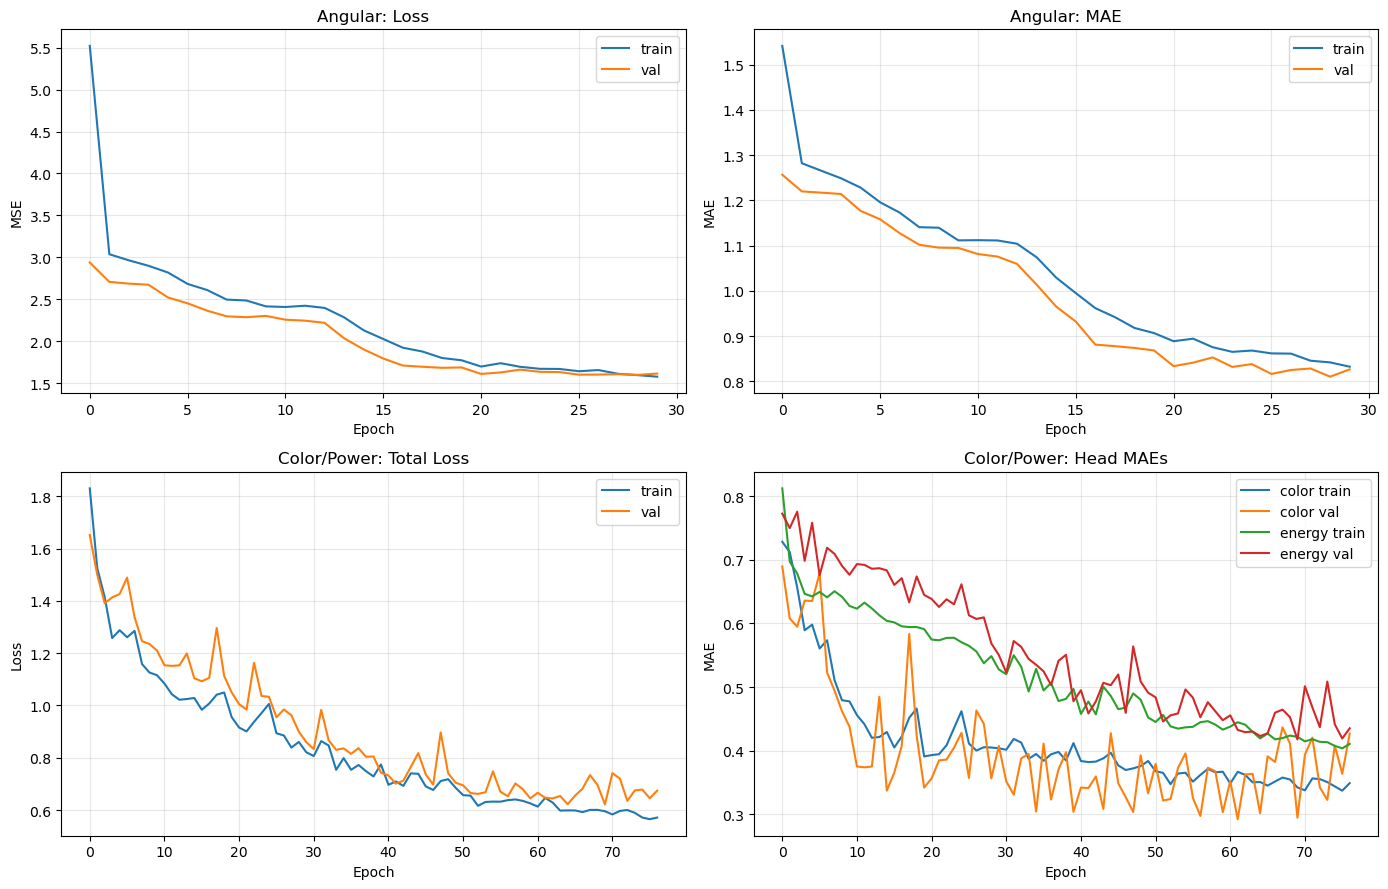

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# angular predictor curves
if "ang_history" in globals() and hasattr(ang_history, "history"):
    h = ang_history.history
    axes[0, 0].plot(h.get("loss", []), label="train")
    axes[0, 0].plot(h.get("val_loss", []), label="val")
    axes[0, 0].set_title("Angular: Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("MSE")
    axes[0, 0].legend()

    axes[0, 1].plot(h.get("mae", []), label="train")
    axes[0, 1].plot(h.get("val_mae", []), label="val")
    axes[0, 1].set_title("Angular: MAE")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].legend()
else:
    axes[0, 0].text(0.5, 0.5, "Run angular training cell first", ha="center", va="center")
    axes[0, 1].text(0.5, 0.5, "Run angular training cell first", ha="center", va="center")

# color/power predictor curves
if "col_history" in globals() and hasattr(col_history, "history"):
    h = col_history.history
    axes[1, 0].plot(h.get("loss", []), label="train")
    axes[1, 0].plot(h.get("val_loss", []), label="val")
    axes[1, 0].set_title("Color/Power: Total Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()

    axes[1, 1].plot(h.get("color_head_mae", []), label="color train")
    axes[1, 1].plot(h.get("val_color_head_mae", []), label="color val")
    axes[1, 1].plot(h.get("energy_head_mae", []), label="energy train")
    axes[1, 1].plot(h.get("val_energy_head_mae", []), label="energy val")
    axes[1, 1].set_title("Color/Power: Head MAEs")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("MAE")
    axes[1, 1].legend()
else:
    axes[1, 0].text(0.5, 0.5, "Run color/power training cell first", ha="center", va="center")
    axes[1, 1].text(0.5, 0.5, "Run color/power training cell first", ha="center", va="center")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# angular per-dim mae
ang_pred_test = angular_model.predict(ang_test_inputs, verbose=0)
ang_abs_err = np.abs(ang_pred_test - y_ang_test)
ang_dim_mae = ang_abs_err.mean(axis=0)

ang_cols = [
    "pos_cam_x", "pos_cam_y", "pos_cam_z",
    "dir_cam_x", "dir_cam_y", "dir_cam_z",
]
print("Angular overall test MAE:", float(np.mean(ang_dim_mae)))
print("Angular per-dim MAE:")
for name, v in zip(ang_cols, ang_dim_mae):
    print(f"  {name}: {v:.4f}")

# color/power denormalized errors
pred_color_z, pred_energy_z = color_model.predict(X_col_test, verbose=0)
true_color = y_color_test * color_std + color_mean
pred_color = pred_color_z * color_std + color_mean

true_energy_log = y_energy_test * energy_std + energy_mean
pred_energy_log = pred_energy_z * energy_std + energy_mean

color_mae_abs = np.abs(pred_color - true_color).mean(axis=0)
energy_mae_log = np.abs(pred_energy_log - true_energy_log).mean()
energy_true = np.exp(true_energy_log)
energy_pred = np.exp(pred_energy_log)
energy_mae_abs = np.abs(energy_pred - energy_true).mean()
energy_mape = (np.abs(energy_pred - energy_true) / np.clip(np.abs(energy_true), 1e-6, None)).mean() * 100

print("\nColor absolute MAE by channel (0-1 scale):", np.round(color_mae_abs, 4))
print("Energy MAE in log-space:", float(energy_mae_log))
print("Energy MAE in original scale:", float(energy_mae_abs))
print("Energy MAPE (%):", float(energy_mape))

Angular overall test MAE: 0.8009269833564758
Angular per-dim MAE:
  pos_cam_x: 2.1643
  pos_cam_y: 0.7168
  pos_cam_z: 0.9405
  dir_cam_x: 0.5439
  dir_cam_y: 0.1798
  dir_cam_z: 0.2603

Color absolute MAE by channel (0-1 scale): [0.069  0.0684 0.0803]
Energy MAE in log-space: 0.1945473551750183
Energy MAE in original scale: 830.450927734375
Energy MAPE (%): 19.516582489013672


In [ ]:
def summarize_targets(name, arr):
    arr = np.asarray(arr)
    print(f"{name} shape={arr.shape}")
    print("  min:", np.round(arr.min(axis=0), 4))
    print("  max:", np.round(arr.max(axis=0), 4))
    print("  mean:", np.round(arr.mean(axis=0), 4))
    print("  std:", np.round(arr.std(axis=0), 4))

print("Angular target summary (all/train/val/test):")
summarize_targets("all", y_ang)
summarize_targets("train", y_ang_train)
summarize_targets("val", y_ang_val)
summarize_targets("test", y_ang_test)

mean_pred = y_ang_train.mean(axis=0, keepdims=True)
baseline_mae = np.abs(y_ang_test - mean_pred).mean(axis=0)
model_mae = np.abs(angular_model.predict(ang_test_inputs, verbose=0) - y_ang_test).mean(axis=0)
print("\nAngular baseline per-dim MAE:", np.round(baseline_mae, 4))
print("Angular model per-dim MAE:", np.round(model_mae, 4))
print("Improvement vs baseline (positive is better):", np.round(baseline_mae - model_mae, 4))

Angular target summary (all/train/val/test):
all shape=(1473, 6)
  min: [ -3.9909  -3.0671 -15.2535  -0.9958  -0.9888  -0.9885]
  max: [ 3.9752  4.015  -7.302   0.9958  0.7818  0.9993]
  mean: [ 7.40000e-03  9.21500e-01 -1.08318e+01 -3.80000e-03 -2.15400e-01
 -1.06100e-01]
  std: [2.4382 1.9362 2.3203 0.6096 0.484  0.5801]
train shape=(942, 6)
  min: [ -3.9909  -3.0671 -15.2535  -0.9958  -0.9888  -0.9885]
  max: [ 3.9752  4.015  -7.302   0.9958  0.7818  0.9993]
  mean: [ -0.0668   0.9262 -10.7972   0.0147  -0.2166  -0.1147]
  std: [2.4101 1.9494 2.3296 0.6025 0.4873 0.5824]
val shape=(236, 6)
  min: [ -3.9909  -3.0671 -15.1677  -0.9958  -0.9888  -0.9885]
  max: [ 3.9752  4.015  -7.302   0.9958  0.7818  0.9779]
  mean: [  0.141    0.9318 -10.7699  -0.0372  -0.2179  -0.1216]
  std: [2.4984 1.9538 2.2186 0.6246 0.4884 0.5547]
test shape=(295, 6)
  min: [ -3.9909  -3.0671 -15.2535  -0.9694  -0.9888  -0.9885]
  max: [ 3.8699  4.015  -7.302   0.9958  0.7818  0.9993]
  mean: [  0.1375   0.898

In [ ]:
legacy_targets = legacy_filtered[target_cols_ang].to_numpy(dtype=np.float32)
new_targets = angular_df[target_cols_ang].to_numpy(dtype=np.float32)

print("Legacy target mean:", np.round(legacy_targets.mean(axis=0), 4))
print("New target mean:", np.round(new_targets.mean(axis=0), 4))
print("Legacy target std:", np.round(legacy_targets.std(axis=0), 4))
print("New target std:", np.round(new_targets.std(axis=0), 4))

base_ang_model = keras.models.load_model(ANGULAR_MODEL_PATH)
base_pred = base_ang_model.predict(ang_test_inputs, verbose=0)
base_mae = np.abs(base_pred - y_ang_test).mean(axis=0)
ft_pred = angular_model.predict(ang_test_inputs, verbose=0)
ft_mae = np.abs(ft_pred - y_ang_test).mean(axis=0)

print("\nBase model per-dim MAE on new test:", np.round(base_mae, 4))
print("Fine-tuned model per-dim MAE on new test:", np.round(ft_mae, 4))

Legacy target mean: [-0.1361  2.1891 -2.2439  0.0289 -0.6024 -0.3096]
New target mean: [ 7.40000e-03  9.21500e-01 -1.08318e+01 -3.80000e-03 -2.15400e-01
 -1.06100e-01]
Legacy target std: [1.5605 1.2572 1.6371 0.4374 0.3545 0.4727]
New target std: [2.4382 1.9362 2.3203 0.6096 0.484  0.5801]

Base model per-dim MAE on new test: [2.499  1.6953 8.6298 0.704  0.423  0.5306]
Fine-tuned model per-dim MAE on new test: [2.1643 0.7168 0.9405 0.5439 0.1798 0.2603]


In [40]:
print("--- ANGULAR ---")
print("Test loss:", float(ang_test_loss))
print("Test MAE:", float(ang_test_mae))
print("Last train loss/mae:", float(ang_history.history["loss"][-1]), float(ang_history.history["mae"][-1]))
print("Last val loss/mae:", float(ang_history.history["val_loss"][-1]), float(ang_history.history["val_mae"][-1]))
print("Best val loss epoch:", int(np.argmin(ang_history.history["val_loss"])) + 1)
print("Per-dim MAE:", np.round(model_mae, 4))
print("Baseline per-dim MAE:", np.round(baseline_mae, 4))
print("Delta (baseline - model):", np.round(baseline_mae - model_mae, 4))

print("\n--- COLOR/POWER ---")
print("Eval vector:", [float(x) for x in col_eval])
print("Last train total loss:", float(col_history.history["loss"][-1]))
print("Last val total loss:", float(col_history.history["val_loss"][-1]))
print("Last train color/energy MAE:", float(col_history.history["color_head_mae"][-1]), float(col_history.history["energy_head_mae"][-1]))
print("Last val color/energy MAE:", float(col_history.history["val_color_head_mae"][-1]), float(col_history.history["val_energy_head_mae"][-1]))
print("Best val loss epoch:", int(np.argmin(col_history.history["val_loss"])) + 1)
print("Color abs MAE (0-1):", np.round(color_mae_abs, 4))
print("Energy log-MAE:", float(energy_mae_log))
print("Energy MAE:", float(energy_mae_abs))
print("Energy MAPE (%):", float(energy_mape))

--- ANGULAR ---
Test loss: 1.5164296627044678
Test MAE: 0.8009269833564758
Last train loss/mae: 1.5763270854949951 0.8321249485015869
Last val loss/mae: 1.6132656335830688 0.8262642621994019
Best val loss epoch: 29
Per-dim MAE: [2.1643 0.7168 0.9405 0.5439 0.1798 0.2603]
Baseline per-dim MAE: [2.2071 1.5948 2.0513 0.5518 0.3987 0.5128]
Delta (baseline - model): [0.0429 0.878  1.1108 0.0079 0.2189 0.2525]

--- COLOR/POWER ---
Eval vector: [0.6014021039009094, 0.3046806752681732, 0.382347047328949, 0.31171470880508423, 0.4079190492630005]
Last train total loss: 0.5710874795913696
Last val total loss: 0.6742570400238037
Last train color/energy MAE: 0.3490133285522461 0.41067183017730713
Last val color/energy MAE: 0.42689213156700134 0.43513980507850647
Best val loss epoch: 70
Color abs MAE (0-1): [0.069  0.0684 0.0803]
Energy log-MAE: 0.1945473551750183
Energy MAE: 830.450927734375
Energy MAPE (%): 19.516582489013672
